### Perceptron

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to -1 and 1
        y_ = np.where(y > 0, 1, -1)

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                # Calculate the linear output
                linear_output = np.dot(x_i, self.weights) + self.bias
                # Activation function (step function)
                y_predicted = np.where(linear_output >= 0, 1, -1)

                # Update weights if there's a misclassification
                if y_predicted != y_[idx]:
                    update = self.learning_rate * y_[idx]
                    self.weights += update * x_i
                    self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

print("Perceptron class defined.")

Perceptron class defined.


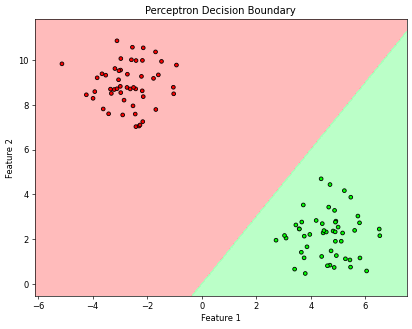

Accuracy: 1.00


In [3]:
from sklearn.datasets import make_blobs

# Generate some synthetic data
X, y = make_blobs(n_samples=100, n_features=2, centers=2, cluster_std=1.0, random_state=42)

# Create a Perceptron instance and fit the data
perceptron = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron.fit(X, y)

# Plot the decision boundary
def plot_decision_boundary(X, y, model):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFBB'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.figure(figsize=(8, 6), dpi=60)
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Perceptron Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(X, y, perceptron)

# Evaluate accuracy (optional)
y_pred = perceptron.predict(X)
accuracy = np.sum(y_pred == np.where(y > 0, 1, -1)) / len(y)
print(f"Accuracy: {accuracy:.2f}")